In [4]:
# Setup: load artifacts produced by 01_analysis.ipynb
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.utils import evaluate, CLUSTER_LABELS, NUMERIC_COLS

DATA_PATH = ROOT / 'data' / 'vehicles.csv'
ART_PATH  = ROOT / 'artifacts'

predictions       = pd.read_parquet(ART_PATH / 'predictions.parquet')
coefficients      = pd.read_parquet(ART_PATH / 'coefficients.parquet')
per_cluster_coefs = pd.read_parquet(ART_PATH / 'per_cluster_coefficients.parquet')
metrics           = json.loads((ART_PATH / 'metrics.json').read_text())

predictions['segment']        = predictions['cluster'].map(CLUSTER_LABELS)
per_cluster_coefs['segment']  = per_cluster_coefs['cluster'].map(CLUSTER_LABELS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Used Car Price Drivers — Findings for Dealers

## Executive Summary

We analyzed roughly 356,000 used vehicle listings from a large public dataset to identify which features have the largest impact on sale price. Our final model — a Ridge regression with polynomial features, fit separately on eight market segments — explains approximately **70% of the variation in used car prices**, predicting prices to within a **median error of approximately $4,600**.

The remaining variation depends on factors not captured in the listing data — photos, exact trim level, free-text descriptions, listing recency, regional supply — but the headline drivers are consistent and directly actionable for inventory decisions.

## Top Drivers Across the Whole Market

Across all listings, the features below have the largest effect on sale price. Green bars push price up, red bars push it down. Coefficients are computed on standardized features against the log of price, so a coefficient of roughly +0.30 corresponds to about a 35% price premium per standard-deviation increase in that feature.

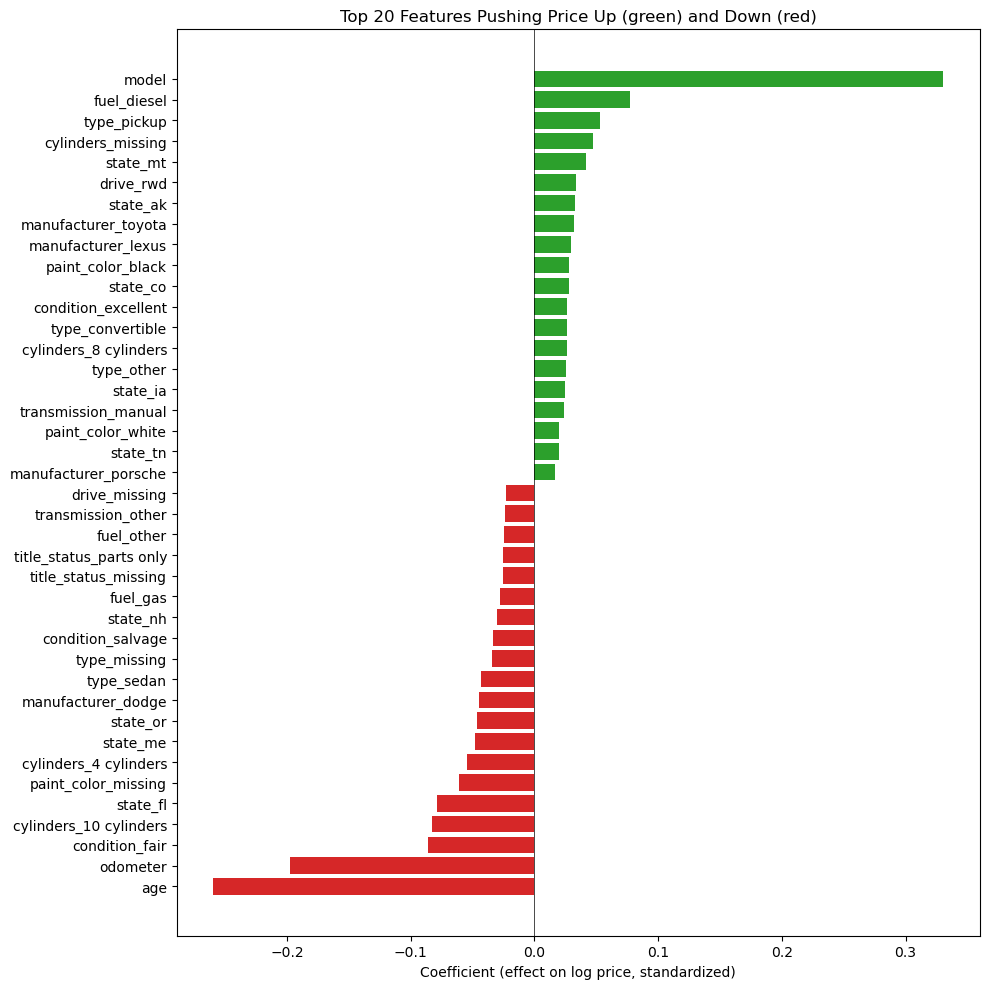

In [5]:
top_n = 20
sorted_coefs = coefficients.assign(abs_coef=coefficients['coefficient'].abs())
top_pos = sorted_coefs.nlargest(top_n, 'coefficient')
top_neg = sorted_coefs.nsmallest(top_n, 'coefficient')
top_features = pd.concat([top_pos, top_neg]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (effect on log price, standardized)')
ax.set_title(f'Top {top_n} Features Pushing Price Up (green) and Down (red)')
plt.tight_layout()
plt.show()

### Top Factors That Increase Price

In rough order of impact:

1. **Specific make/model premium.** The single biggest predictor is the make and model of the vehicle. Some models command consistent premiums regardless of other factors.
2. **Lower mileage.** Discounts grow faster as a vehicle approaches and crosses ~150,000 miles. Vehicles below 100,000 miles carry the strongest premiums.
3. **Condition rating.** Vehicles listed as `excellent`, `like new`, or `new` sell for substantially more than those listed as `good` or `fair`.
4. **Vehicle type.** Pickups, trucks, and certain coupes/convertibles command premiums over sedans and hatchbacks of comparable age and mileage.
5. **Higher cylinder count.** 8/10/12-cylinder engines correlate with higher prices, primarily because they appear in the truck and luxury segments.
6. **Diesel fuel.** Diesel vehicles, particularly trucks, command a premium over gasoline equivalents.
7. **Clean title.** Title status is one of the most influential categorical features — see the downside below.

### Top Factors That Decrease Price

1. **Salvage, rebuilt, or "parts only" titles.** These reduce expected sale price by roughly 30–50%, even when other features (year, mileage, model) are favorable. Title status is the largest controllable risk factor in inventory decisions.
2. **High mileage.** Vehicles above 200,000 miles see steep price discounts, and the discount per additional mile accelerates above this threshold.
3. **Vehicle age.** The depreciation effect compounds, particularly past the 10-year mark.
4. **Poor condition.** "Fair" or "salvage" condition listings sell for substantially less than otherwise comparable vehicles.
5. **Smaller engines.** 3/4-cylinder vehicles (mostly economy compacts) sell at a discount, partly because they are concentrated in lower-priced segments.
6. **Missing data in the listing.** Listings missing key fields (condition, cylinders, drive type) sell for less, likely because the market is reading missing data as a quality signal.

### Geographic Effects

State-level effects are present but smaller than vehicle-level effects. Some states show modest premiums (likely reflecting local supply/demand for particular vehicle types — e.g., trucks in the Mountain West), but state of listing is a second-order factor compared to vehicle attributes.

## Market Segments

The used-car market is not uniform — listings cluster into eight distinct segments with different price levels and pricing dynamics. Two segments (marked ⭐) benefit substantially from segment-specific pricing models and should be treated as separate inventory categories with their own sourcing rules.

| Segment | Share | Median price | Defining traits |
|---|---|---|---|
| Mainstream SUVs | 19% | $9,700 | V6, Jeep / Ford / Honda; family vehicles |
| Older V8 gas pickups | 14% | $18,000 | F-150 / Silverado / Sierra daily-driver pickups |
| HD diesel trucks | 6% | $32,500 | F-250/350 diesels, Ram HDs; premium work trucks |
| **Newer premium pickups ⭐** | 11% | $29,600 | ~8 years, ~24k miles; GMC Sierra / premium Silverados |
| Economy sedans | 13% | $7,700 | 4-cyl, Honda/Toyota; high-volume cheap sedans |
| Mid-tier mixed | 13% | $16,700 | Heterogeneous mid-aged group; sparse condition data |
| Sparse listings | 16% | $9,500 | Multiple missing fields — a quality signal in itself |
| **Newer EV / alt-fuel ⭐** | 6% | $28,600 | EVs, hybrids, plug-ins; very low miles for the age |

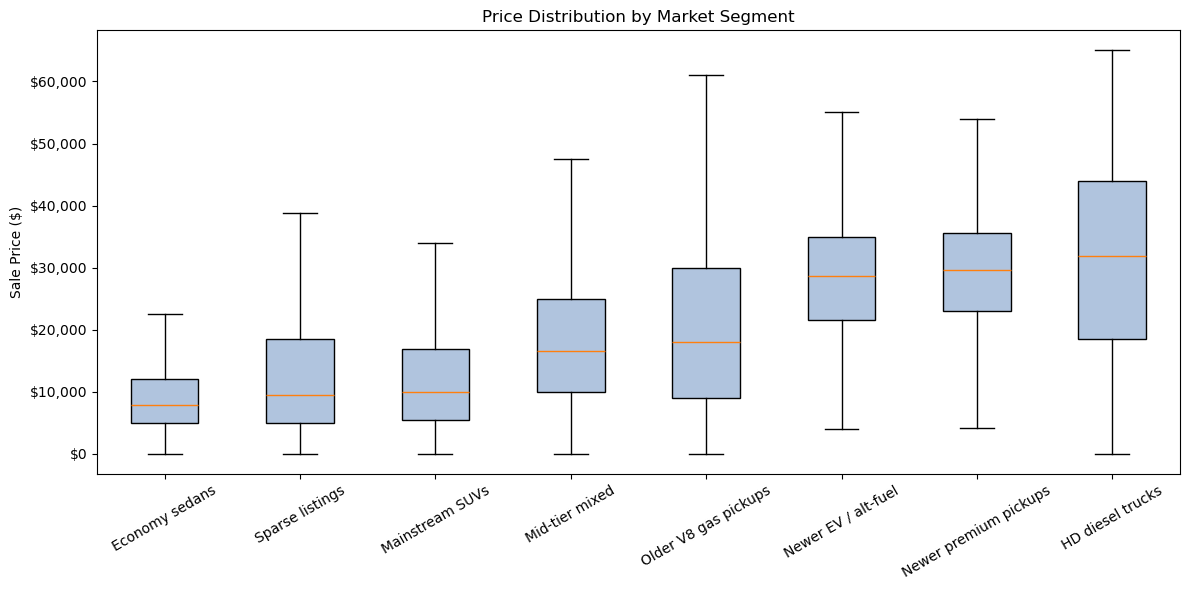

In [8]:
# Price distribution per segment, sorted by median
ordered_segments = (predictions.groupby('segment')['actual']
                    .median()
                    .sort_values()
                    .index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
data = [predictions.loc[predictions['segment'] == s, 'actual'].values for s in ordered_segments]
bp = ax.boxplot(data, tick_labels=ordered_segments, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')

ax.set_ylabel('Sale Price ($)')
ax.set_title('Price Distribution by Market Segment')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### What's Different About Each Highlighted Segment

The plots below show, for each highlighted segment, the features whose effects on price differ most from the broader market average. Green bars are features that matter *more* in this segment than typical; red bars are features that matter *less* or work in the opposite direction. These are the pricing rules unique to each segment, useful for understanding what to watch for when sourcing inventory.

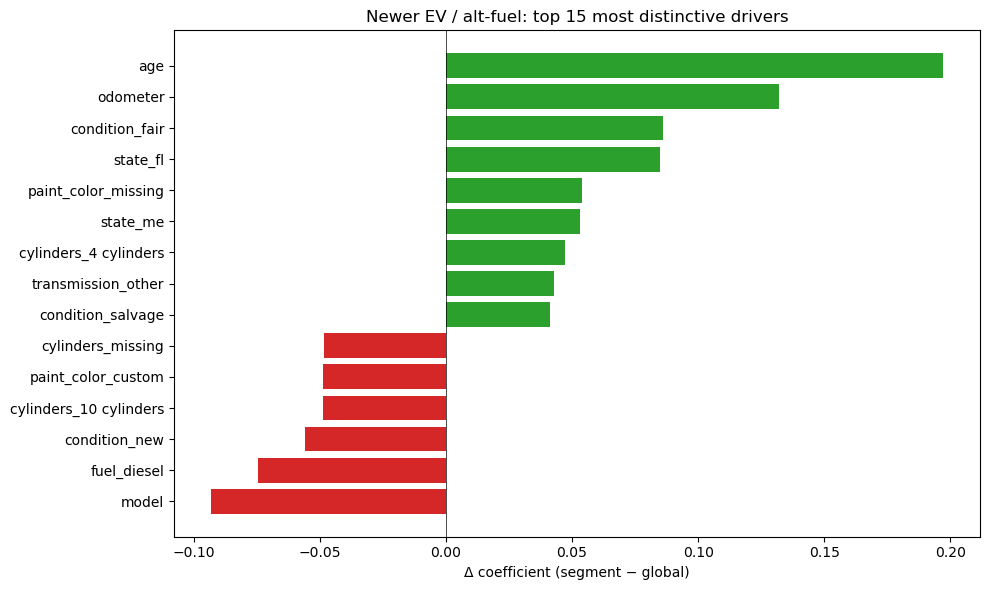

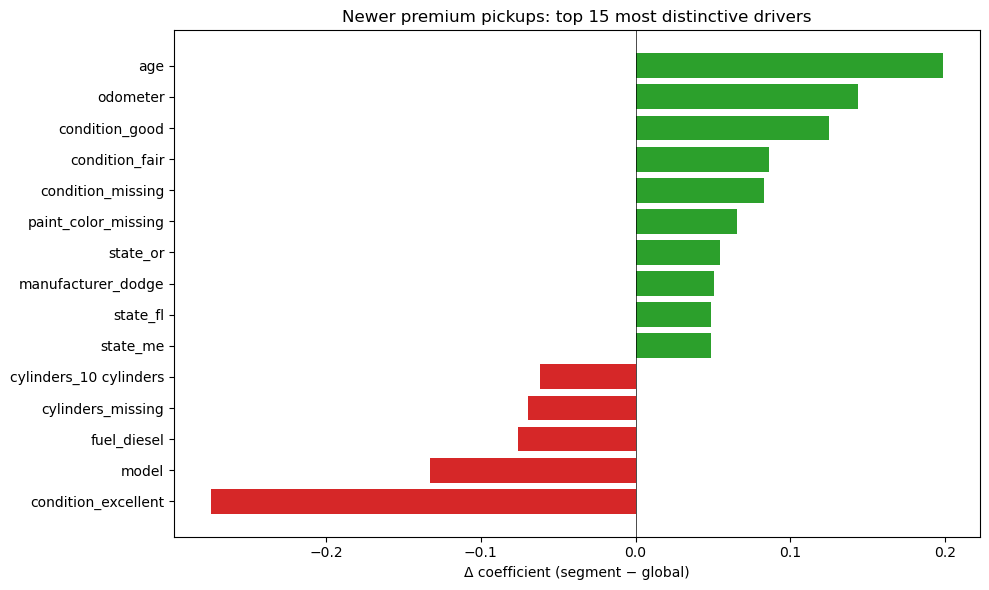

In [7]:
# Compute deltas: how each segment's coefficients differ from the global model
global_coefs = coefficients.set_index('feature')['coefficient']
per_cluster_coefs['global_coef'] = per_cluster_coefs['feature'].map(global_coefs)
per_cluster_coefs['delta']       = per_cluster_coefs['coefficient'] - per_cluster_coefs['global_coef']


def plot_distinctive_drivers(cluster_id, n=15):
    sub = per_cluster_coefs[per_cluster_coefs['cluster'] == cluster_id].copy()
    sub = sub.reindex(sub['delta'].abs().sort_values(ascending=False).index).head(n)
    sub = sub.sort_values('delta')

    colors = ['#d62728' if d < 0 else '#2ca02c' for d in sub['delta']]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sub['feature'], sub['delta'], color=colors)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Δ coefficient (segment − global)')
    ax.set_title(f"{CLUSTER_LABELS[cluster_id]}: top {n} most distinctive drivers")
    plt.tight_layout()
    plt.show()


# Two segments where per-cluster modeling delivered the biggest gains
plot_distinctive_drivers(7)  # Newer EV / alt-fuel
plot_distinctive_drivers(3)  # Newer premium pickups

## Recommendations for Inventory Decisions

1. **Prioritize clean-title inventory.** Salvage and rebuilt vehicles trade at significant discounts — typically 30–50% off comparable clean-title vehicles. Title status is the largest controllable risk factor in sourcing decisions.
2. **Target the 0–10-year, sub-150k-mile sweet spot.** This range captures the bulk of market volume and the most predictable pricing.
3. **Be careful with vehicles approaching 150,000 miles.** Discounts accelerate beyond this threshold — a vehicle at 145k miles is meaningfully more salable than one at 175k miles, even though the difference seems small.
4. **Trucks and pickups are higher-margin opportunities.** They hold value better than sedans of comparable age and mileage. Within the truck market, newer premium pickups (⭐ segment) and HD diesel trucks command the highest prices but also have distinct pricing logic — see segment-specific notes.
5. **Don't over-emphasize cosmetic features.** Paint color and similar cosmetic attributes have weak and inconsistent effects compared to mechanical and structural features.
6. **Treat the highlighted segments as separate inventory categories.** Newer EV/alt-fuel vehicles and newer premium pickups follow distinct depreciation curves from the rest of the market, and the per-segment model captures that. Inventory in either category benefits from segment-specific sourcing rules rather than blanket "any 8-year-old vehicle" heuristics.
7. **Be cautious with sparse listings.** Vehicles with multiple missing fields tend to sell at a discount even when visible features look good — the market is reading missing data as a quality signal.

## Important Caveats

- The model explains ~70% of price variation. The remaining ~30% lives in factors not captured here: listing photos, free-text descriptions, exact trim levels, listing recency, and overall listing quality.
- Predictions are most accurate in the $10k–$30k range; accuracy degrades at the high and low extremes.
- The analysis is based on Craigslist listings, which skew toward private-party transactions; dealer-network pricing patterns may differ.
- The dataset reflects market conditions captured at the time of collection. Significant macro changes (interest rates, fuel prices, supply chain) may shift these effects.
- Vehicles older than ~45 years (pre-1980) were excluded; classic-car pricing follows different dynamics than the daily-use market this report addresses.
- Heavy-duty diesel trucks remain the hardest segment to price accurately. Trim level, engine variant, and tow-package configuration matter substantially within this segment but are not captured in the listing data.

## Suggested Next Steps

For a production pricing tool, two enhancements would meaningfully improve accuracy:

- **Listing-quality signals.** Photo presence, description length, and listing recency are likely strong predictors of sale price independent of vehicle attributes, and would close part of the unexplained-variance gap.
- **Tree-based models.** A Gradient Boosting Regressor on the same feature matrix would likely push accuracy further by capturing non-linear effects across all features (not just the three numeric ones we currently treat that way), at the cost of less direct coefficient interpretability.

The current model is sufficient for inventory strategy decisions but should not be used as a per-vehicle pricing oracle.